## Params

In [14]:
# data exploration
words_count = 5000 # number of words in a dictionary
max_msg_length = 100 # max. length (in words) for a single message
val_set_size = 0.1; test_set_size = 0.1 # sizes of validation and test sets (from 0 to 1)

# PyTorch dataset
batch_size = 32

# training loop
epochs = 25

## Data exploration

In [2]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split





# returns word : index dictionary from words included in data
def encode_words(data, vocab_size=5000):
    word_counts = Counter()

    for text in data['text']:
        words = re.findall(r'\w+', text)
        word_counts.update(words)
        
    top_words = word_counts.most_common(vocab_size)

    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for idx, word in enumerate(top_words, start=2):
        word2idx[word[0]] = idx
        
    return word2idx


# returns a list of encoded messages using word : index dictionary 
def encode_messages(df, word2idx, max_len=100):
    encoded_messages = []
    
    for text in df['text']:
        encoded = [word2idx.get(word, word2idx['<UNK>']) for word in re.findall(r'\w+', text)][:max_len]
        
        if len(encoded) < max_len:
            encoded += ([word2idx['<PAD>']] * (max_len - len(encoded)))
        encoded_messages.append(encoded)
    
    return encoded_messages
    

# getting the data from csv file and 
df_data = pd.read_csv('../data/spam.csv', encoding='latin-1', usecols=[0, 1])      # get data from the file
df_data.columns = ['label', 'text']                                                # rename columns
df_data['label'] = df_data['label'].map({'ham': 0, 'spam': 1})                     # set ham/spam to 0/1
df_data['text'] = df_data['text'].apply(lambda x: x.lower())                       # make all letters lowercase

# split the dataset into train, validation and test sets 
df_train_val, df_test = train_test_split(
    df_data, 
    test_size=test_set_size, 
    random_state=42, 
    stratify=df_data['label']
)
df_train, df_val = train_test_split(
    df_train_val, 
    test_size=val_set_size/(1-test_set_size), 
    random_state=42, 
    stratify=df_train_val['label']
)

# encode datasets (train, validation, test)
word2idx = encode_words(df_train, words_count)
X_train = encode_messages(df_train, word2idx, max_msg_length) 
X_val = encode_messages(df_val, word2idx, max_msg_length) 
X_test = encode_messages(df_test, word2idx, max_msg_length) 
y_train = df_train['label'].values
y_val = df_val['label'].values
y_test = df_test['label'].values
vocab_size = len(word2idx)

## PyTorch dataset 

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


# creating tensors from the data
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# datasets from X and y tensors 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## The model

In [ ]:
import os 

# choose the best available device 
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device.")

# Model definition
class SpamClassifier(nn.Module):
    def __init__(self, vocab_size, embd_dim, max_len):
        super().__init__()
        
        # Layer 1: Embeeding
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embd_dim,
            padding_idx=0
        )
        
        # Layer 2 and 3: dense linear layer
        self.fc1 = nn.Linear(max_len*embd_dim, 32) # l2
        self.fc12 = nn.Linear(32, 8) # l3
        self.relu = nn.ReLU()
        
        self.dropout = nn.Dropout(p=0.3)
        
        # Layer 4: output layer
        self.fc2 = nn.Linear(8, 1)
        
        
    def forward(self, x):
        # embedding the input (batch_size, max_len) -> (batch_size, max_len, embd_dim)
        out = self.embedding(x)
        
        # projecting to a 2-dimension tensor (batch_size, max_len, embd_dim) -> (batch_size, max_len*embd_dim)
        out = out.view(out.size(0), -1)
        
        # second layer with reLU act. func. (batch_size, max_len*embd_dim) -> (batch_size, 64)
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        
        # third layer 
        out = self.relu(self.fc12(out))
        out = self.dropout(out)
        
        # fourth (output) layer (batch_size, 1)
        out = self.fc2(out)
        
        return out 

Using cpu device.


In [5]:
import torch.optim as optim


# first model test
model = SpamClassifier(vocab_size, 64, max_msg_length).to(device)

for batch_X, batch_y in train_dataloader:
    batch_X = batch_X.to(device)
    batch_y = batch_y.to(device)
    
    outputs = model(batch_X)
    break


# MODEL RUN

# loss function
criterion = nn.BCEWithLogitsLoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# one learning step
optimizer.zero_grad()
loss = criterion(outputs, batch_y.unsqueeze(1))

loss.backward() # back-propagation
optimizer.step() # update weights 

print(f"Loss for the 1st batch: {loss.item()}")

Loss for the 1st batch: 0.7202937602996826


## Model training loop

In [41]:
# create model
model = SpamClassifier(vocab_size, 8, max_msg_length).to(device)
# loss function
criterion = nn.BCEWithLogitsLoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


# looses tracking
train_losses = []
val_losses = []


# early cut
best_val_loss = float('inf')

In [42]:
for epoch in range(epochs):
    running_loss_train = 0.0 
    running_loss_val = 0.0 
    print(f"Epoch {epoch+1}:")
    
    # training
    model.train() # set model to training mode
    for batch_X, batch_y in train_dataloader:
        # transfer batches to the designated device
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad() # clear previous gradients
        
        outputs = model(batch_X) # pass batch_X through the model
        
        loss = criterion(outputs, batch_y.unsqueeze(1)) # count the loss
        
        loss.backward() # backprop
        
        optimizer.step() # update weights 
        running_loss_train += loss.item()
        
    running_loss_train /= len(train_dataloader)
    print(f"Train: {running_loss_train}")
    
    # validation
    model.eval()
    with torch.no_grad():
        for batch_X, batch_y in val_dataloader:
                # transfer batches to the designated device
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
            
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y.unsqueeze(1))
                running_loss_val += loss.item()
                
    running_loss_val /= len(val_dataloader)
    print(f"Val: {running_loss_val}")
    
    # for graph
    train_losses.append(running_loss_train)
    val_losses.append(running_loss_val)
            
    # early cut
    if running_loss_val < best_val_loss: 
        best_val_loss = running_loss_val
        torch.save(model.state_dict(), 'best_spam_model.pth')

Epoch 1:
Train: 0.45142749047705105
Val: 0.3308469280600548
Epoch 2:
Train: 0.2849481426179409
Val: 0.2505350034270022
Epoch 3:
Train: 0.19105696813868625
Val: 0.18913465158806908
Epoch 4:
Train: 0.13214845594816974
Val: 0.1616792209032509
Epoch 5:
Train: 0.09252206326595375
Val: 0.1627994997219907
Epoch 6:
Train: 0.0697231836483947
Val: 0.16815886511984798
Epoch 7:
Train: 0.05723226523425962
Val: 0.16773173611404169
Epoch 8:
Train: 0.042488546418358704
Val: 0.17144432361884457
Epoch 9:
Train: 0.036435341276228425
Val: 0.1797350175717535
Epoch 10:
Train: 0.03446115617074871
Val: 0.1997060295414283
Epoch 11:
Train: 0.032450819020492155
Val: 0.2044401323914321
Epoch 12:
Train: 0.023389363907543675
Val: 0.24300504679235424
Epoch 13:
Train: 0.023878572699946483
Val: 0.24018809398532742
Epoch 14:
Train: 0.021785816261996972
Val: 0.24170587580334135
Epoch 15:
Train: 0.018320962344192334
Val: 0.24063019306049682
Epoch 16:
Train: 0.017582135663932213
Val: 0.25639521320570363
Epoch 17:
Train: 0

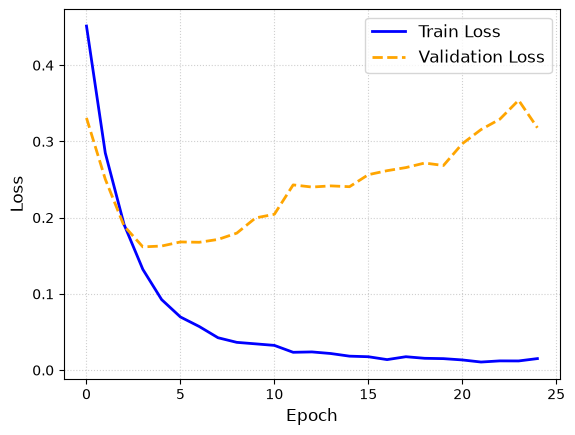

0.1616792209032509


In [43]:
# Looses graph
import matplotlib.pyplot as plt

plt.Figure()
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--', linewidth=2)

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12) 
plt.grid(True, linestyle=':', alpha=0.6) 

plt.show()

print(best_val_loss)


### Losses depending on embedding dimensions 
**64**:
Epoch 0:
Train: 0.3025031490517514
Val: 0.16690566101007992
Epoch 1:
Train: 0.06341438881520714
Val: 0.14783971917091143
Epoch 2:
Train: 0.016922116277938975
Val: 0.15372456307522953
Epoch 3:
Train: 0.006832427846217927
Val: 0.18009851653025383
Epoch 4:
Train: 0.0039788614584332594
Val: 0.1953120688817257
**16**:
Epoch 0:
Train: 0.40273440671818594
Val: 0.2620010959605376
Epoch 1:
Train: 0.16404337342828512
Val: 0.18730969457990593
Epoch 2:
Train: 0.07884245558774897
Val: 0.1713393541673819
Epoch 3:
Train: 0.03884169784308012
Val: 0.18128306418657303
Epoch 4:
Train: 0.02111568959163768
Val: 0.1821897073338429
**8**:
Epoch 0:
Train: 0.4431677566042968
Val: 0.32420581413639915
Epoch 1:
Train: 0.2138661980096783
Val: 0.2273005781074365
Epoch 2:
Train: 0.12447127439081669
Val: 0.1833917068110572
Epoch 3:
Train: 0.07934034034343702
Val: 0.1639438250826465
Epoch 4:
Train: 0.05257221608023558
Val: 0.15728711667988035